In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/hotel_bookings 2.csv")

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/7/2015


In [5]:
#basic inpection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [10]:
df.select_dtypes(include="object").columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

In [11]:
df.select_dtypes(include=np.number).columns

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

In [12]:
#missing value analysis
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing = missing[missing["missing_count"] > 0]
missing.sort_values("missing_percentage", ascending=False)

,missing_count,missing_percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


In [13]:
df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [14]:
df["is_canceled"].value_counts(normalize=True) * 100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

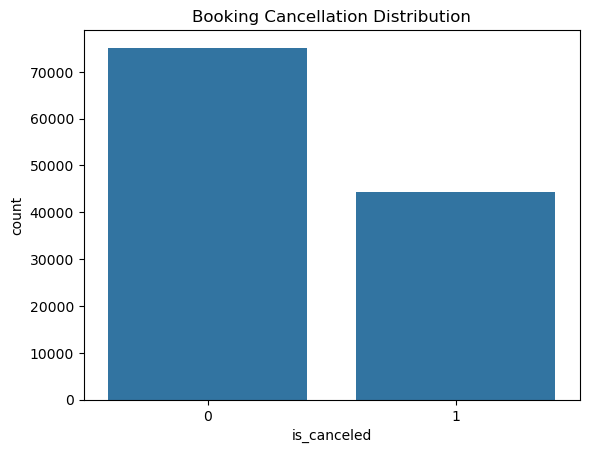

In [ ]:
#this will tells us the data is imbalnce or not 

sns.countplot(data=df, x="is_canceled")
plt.title("Booking Cancellation Distribution")
plt.show()

In [17]:
df.groupby("hotel")["is_canceled"].mean()*100

hotel
City Hotel      41.726963
Resort Hotel    27.763355
Name: is_canceled, dtype: float64

In [18]:
df.groupby("deposit_type")["is_canceled"].mean()*100

deposit_type
No Deposit    28.377022
Non Refund    99.362446
Refundable    22.222222
Name: is_canceled, dtype: float64

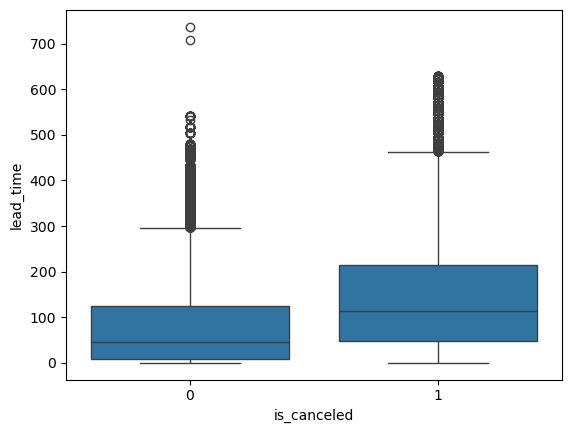

In [19]:
sns.boxplot(data=df, x="is_canceled", y="lead_time")
plt.show()

In [20]:
df.groupby("is_canceled")["lead_time"].mean()

is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

In [21]:
pd.crosstab(
    df["deposit_type"],
    df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
deposit_type,,
No Deposit,0.716230,0.283770
Non Refund,0.006376,0.993624
Refundable,0.777778,0.222222


In [22]:
pd.crosstab(
    df["market_segment"],
    df["is_canceled"],
    normalize="index"
).sort_values(1, ascending=False)

is_canceled,0,1
market_segment,,
Undefined,0.000000,1.000000
Groups,0.389380,0.610620
Online TA,0.632789,0.367211
Offline TA/TO,0.656840,0.343160
Aviation,0.780591,0.219409
Corporate,0.812653,0.187347
Direct,0.846581,0.153419
Complementary,0.869448,0.130552


In [23]:
pd.crosstab(
    df["customer_type"],
    df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
customer_type,,
Contract,0.690383,0.309617
Group,0.897747,0.102253
Transient,0.592537,0.407463
Transient-Party,0.745701,0.254299


In [24]:
df.groupby("previous_cancellations")["is_canceled"].mean()

previous_cancellations
0     0.339061
1     0.944307
2     0.327586
3     0.307692
4     0.225806
5     0.105263
6     0.318182
11    0.285714
13    0.916667
14    1.000000
19    1.000000
21    1.000000
24    1.000000
25    1.000000
26    1.000000
Name: is_canceled, dtype: float64

In [25]:
df.groupby("total_of_special_requests")["is_canceled"].mean()

total_of_special_requests
0    0.477204
1    0.220249
2    0.220989
3    0.178614
4    0.105882
5    0.050000
Name: is_canceled, dtype: float64

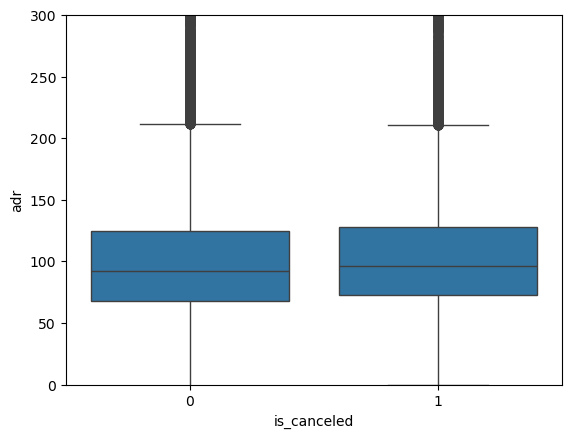

In [26]:
sns.boxplot(data=df, x="is_canceled", y="adr")
plt.ylim(0, 300)
plt.show()